# Student Performance Prediction Using Machine Learning


This project performs student math scores using demographic and academic performance data through machine learning regression techniques

# Importing Libraries

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

#Loading Dataset

In [35]:
df=pd.read_csv("/content/StudentsPerformance.csv")
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


#Data Exploration

This section analyzes datset structutre,feature types,missing values,and staristical properties of the data.

In [36]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [37]:
df.describe()


,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


#Correlation analysis

Correlation Analysis helps identify realtionships between numerical variables and understand which features strongly influence math scores(target variable)

In [38]:
correlation=df[["math score","reading score","writing score"]].corr()
correlation

,math score,reading score,writing score
math score,1.000000,0.817580,0.802642
reading score,0.817580,1.000000,0.954598
writing score,0.802642,0.954598,1.000000


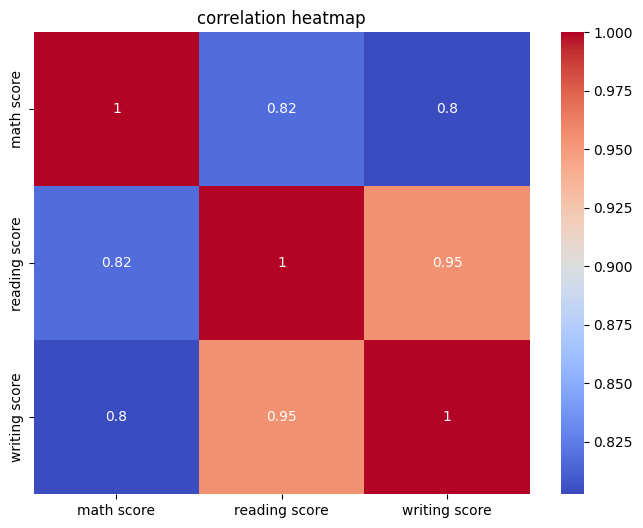

In [39]:
plt.figure(figsize=(8,6))
sns.heatmap(correlation,annot=True,cmap="coolwarm")
plt.title("correlation heatmap")
plt.show()

#Data Preprocessing

Categorical feaatures were converted to numerical format using one-hot encoding to make the datset suitable for machine learning models.

In [40]:
df_encoded=pd.get_dummies(df,drop_first=True)
df_encoded.head()

,math score,reading score,writing score,gender_male,race/ethnicity_group B,race/ethnicity_group C,race/ethnicity_group D,race/ethnicity_group E,parental level of education_bachelor's degree,parental level of education_high school,parental level of education_master's degree,parental level of education_some college,parental level of education_some high school,lunch_standard,test preparation course_none
0,72,72,74,False,True,False,False,False,True,False,False,False,False,True,True
1,69,90,88,False,False,True,False,False,False,False,False,True,False,True,False
2,90,95,93,False,True,False,False,False,False,False,True,False,False,True,True
3,47,57,44,True,False,False,False,False,False,False,False,False,False,False,True
4,76,78,75,True,False,True,False,False,False,False,False,True,False,True,True


#Feature and Target Selection

In [41]:
X=df_encoded.drop("math score",axis=1)
y=df_encoded["math score"]
print(X.head())
print(y.head())


   reading score  writing score  gender_male  race/ethnicity_group B  \
0             72             74        False                    True   
1             90             88        False                   False   
2             95             93        False                    True   
3             57             44         True                   False   
4             78             75         True                   False   

   race/ethnicity_group C  race/ethnicity_group D  race/ethnicity_group E  \
0                   False                   False                   False   
1                    True                   False                   False   
2                   False                   False                   False   
3                   False                   False                   False   
4                    True                   False                   False   

   parental level of education_bachelor's degree  \
0                                           True   


#

#Train-Test Split

The dataset was divided into training and testing sets to evaluate model performance on unseen data.


In [42]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
print("training data shape:",X_train.shape)
print("testing data shape:",X_test.shape)


training data shape: (800, 14)
testing data shape: (200, 14)


#Model Training

Linear Regression was used to predict continuous numerical math scores based on input features.

In [43]:
model=LinearRegression()
model.fit(X_train,y_train)
print("model training completed")

model training completed


#Model Evaluation

Regression evaluates metrics such as MAE,RMSE,R2 score were used to measure prediction performance.

In [44]:
y_pred=model.predict(X_test)
print(y_pred)

[76.3879697  58.88597004 76.99026483 76.85180448 87.62737816 79.0140238
 64.65460865 53.00791885 74.18471015 49.21353815 52.94765047 36.66906418
 67.9139255  52.27725558 86.71848338 70.53070205 51.95556639 46.8314386
 48.82375101 52.72669531 73.88582984 38.88612362 57.38074421 36.32839723
 78.14908978 81.79995075 75.3849409  46.1184787  31.03596334 49.90094972
 65.98409138 70.4116652  60.5061564  83.73986218 84.43184961 46.07265627
 76.10135181 70.20596817 65.85782103  3.76186106 78.49792748 67.25291552
 67.97175998 60.2734092  79.67385074 67.60005539 72.24589185 24.76000748
 85.95581153 70.08842684 75.41268803 66.79864565 81.16502181 45.6635254
 66.11051928 67.32545668 86.13600492 58.72739768 82.23614367 81.21768838
 47.23421792 72.04512129 70.64302698 55.92646405 86.31798368 63.86663678
 59.48657443 55.91061249 57.20534331 82.14529335 71.7699997  80.48800131
 58.37254249 46.38271551 61.23110052 85.00868631 84.24763549 60.29504754
 59.29079503 53.21863924 63.67390126 41.11157129 78.88

In [45]:
mae=mean_absolute_error(y_test,y_pred)
mse=mean_squared_error(y_test,y_pred)
rmse=np.sqrt(mse)
r2=r2_score(y_test,y_pred)
print("MAE:",mae)
print("MSE:",mse)
print("RMSE:",rmse)
print("R2 SCORE:",r2)

MAE: 4.214763142474851
MSE: 29.095169866715487
RMSE: 5.393993869732843
R2 SCORE: 0.8804332983749565


##Visualization of predictions

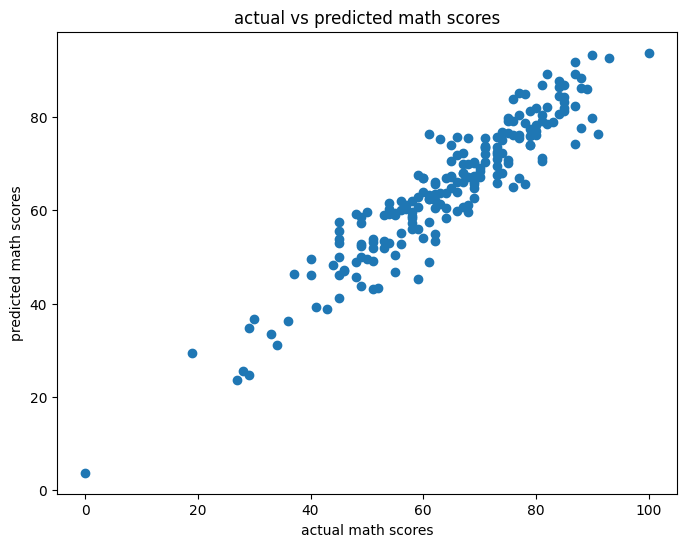

In [46]:
plt.figure(figsize=(8,6))
plt.scatter(y_test,y_pred)
plt.xlabel("actual math scores")
plt.ylabel("predicted math scores")
plt.title("actual vs predicted math scores")
plt.show()

#Model Comparison

In [47]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

In [48]:
linear_model=LinearRegression()
decesion_tree_model=DecisionTreeRegressor(random_state=42)
random_forest_model=RandomForestRegressor(random_state=42)
linear_model.fit(X_train,y_train)
decesion_tree_model.fit(X_train,y_train)
random_forest_model.fit(X_train,y_train)
print("All models trained successfully")

All models trained successfully


In [49]:
linear_pred=linear_model.predict(X_test)
decesion_tree_pred=decesion_tree_model.predict(X_test)
random_forest_pred=random_forest_model.predict(X_test)


In [50]:
linear_r2=r2_score(y_test,linear_pred)
decesion_tree_r2=r2_score(y_test,decesion_tree_pred)
random_forest_r2=r2_score(y_test,random_forest_pred)
print("Linear regression r2 score:",linear_r2)
print("Decesion tree r2 score:",decesion_tree_r2)
print("Random forest r2 score:",random_forest_r2)


Linear regression r2 score: 0.8804332983749565
Decesion tree r2 score: 0.7107320505107291
Random forest r2 score: 0.8491990721184489


#Feature Importance

In [51]:
feature_importance=pd.DataFrame({
    "Feature":X.columns,"Importance":random_forest_model.feature_importances_})
feature_importance=feature_importance.sort_values(by="Importance",ascending=False)
print(feature_importance)

                                          Feature  Importance
0                                   reading score    0.562565
1                                   writing score    0.234740
2                                     gender_male    0.120780
12                                 lunch_standard    0.015490
13                   test preparation course_none    0.011255
6                          race/ethnicity_group E    0.011117
10       parental level of education_some college    0.008142
4                          race/ethnicity_group C    0.006833
5                          race/ethnicity_group D    0.006085
8         parental level of education_high school    0.006068
3                          race/ethnicity_group B    0.005132
11   parental level of education_some high school    0.005018
7   parental level of education_bachelor's degree    0.004757
9     parental level of education_master's degree    0.002018


##Feature Imporatnce Visualization

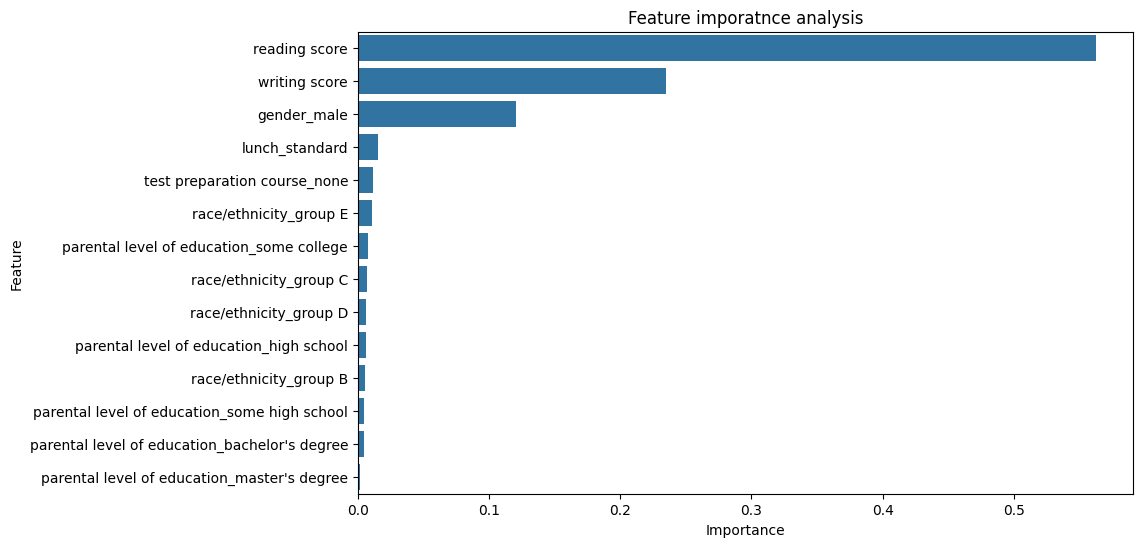

In [52]:
plt.figure(figsize=(10,6))
sns.barplot(
    x="Importance",y="Feature",data=feature_importance
)
plt.title("Feature imporatnce analysis")
plt.show()

#Model Saving and Loading Using Pickle


In [53]:
import pickle

In [54]:
with open("student_performance_model.pkl","wb") as file:
  pickle.dump(linear_model,file)
print("Model successfully saved")

Model successfully saved


In [55]:
with open("student_performance_model.pkl","rb") as file:
  loaded_model=pickle.load(file)
print("Model loaded successfully")

Model loaded successfully


In [56]:
sample_data=X_test.iloc[[0]]
sample_prediction=loaded_model.predict(sample_data)
print("Predicted math score:",sample_prediction[0])
print("Actual math score",y_test.iloc[0])

Predicted math score: 76.38796970470761
Actual math score 91


#Predict New Student Score

In [57]:
print(X.columns)

Index(['reading score', 'writing score', 'gender_male',
       'race/ethnicity_group B', 'race/ethnicity_group C',
       'race/ethnicity_group D', 'race/ethnicity_group E',
       'parental level of education_bachelor's degree',
       'parental level of education_high school',
       'parental level of education_master's degree',
       'parental level of education_some college',
       'parental level of education_some high school', 'lunch_standard',
       'test preparation course_none'],
      dtype='object')


In [58]:
new_student =pd.DataFrame({
    'reading score':[85],'writing score':[82],'gender_male':[1],
    'race/ethnicity_group B':[0],
    'race/ethnicity_group C':[1],
       'race/ethnicity_group D':[0], 'race/ethnicity_group E':[0],
       'parental level of education_bachelor\'s degree':[1],
       'parental level of education_high school':[0],
       'parental level of education_master\'s degree':[0],
       'parental level of education_some college':[0],
       'parental level of education_some high school':[0],
       'lunch_standard':[1],
       'test preparation course_none':[0]
})
predicted_score=loaded_model.predict(new_student)
print("predicted math score: ", predicted_score[0])

predicted math score:  83.76199163806841
